# Full circuit for 1+1d SU(2) Trotter simulation using the LSH formulation with $L=4$, $\Lambda=2$

In this notebook, dt is fixed to 1.25, executing circuits upto 6 trotter steps.  
We do not care about Trotterization errors, but we focused on the evaluation of hardware performances by comparing to the noiselss simulator.  
We are trying to mitigate errors by post-selection or depolarizing noise model.  
To estimate depolarizing noise probability, we use three different approaches.

## Setup

In [1]:
!pip list 

Package                                  Version
---------------------------------------- -----------
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.2
aiohttp-cors                             0.8.1
aiosignal                                1.4.0
annotated-types                          0.7.0
anyio                                    4.11.0
appnope                                  0.1.4
argon2-cffi                              25.1.0
argon2-cffi-bindings                     25.1.0
arrow                                    1.4.0
asttokens                                3.0.0
async-lru                                2.0.5
attrs                                    25.4.0
babel                                    2.17.0
backports.zstd                           1.3.0
beautifulsoup4                           4.14.2
bleach                                   6.2.0
cachetools                               6.2.4
certifi                                  2024

In [2]:
import sys
sys.path.append('../')

import numpy as np
import scipy
import jax
import jax.numpy as jnp
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter, CircuitInstruction
from qiskit.circuit.library.standard_gates import XGate
from qiskit.transpiler import PassManager, StagedPassManager, generate_preset_pass_manager
from qiskit.quantum_info import Operator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeTorino, FakeKawasaki
from qiskit_aer import AerSimulator

import lsh_qudit.set_rccx_inverse
from lsh_qudit.validator_jax import validate_circuit
from lsh_qudit.agl import physical_states, boundary_conditions
from lsh_qudit.hamiltonian_nn import (mass_term, electric_12_term,
                                            electric_3f_term, electric_3b_term,
                                            hopping_term_config, hopping_term_site)
from lsh_qudit.matrices import hopping_site_hamiltonian
from lsh_qudit.trotter_nn import trotter_step_circuit
from lsh_qudit.precompiler import lsh_qudit_precompiler
from lsh_qudit.utils import QubitPlacement, sort_qubits, draw_circuit, clean_array, op_matrix

jax.config.update('jax_enable_x64', True)

mass_mu = Parameter('$\mu$')
interaction_x = Parameter('x')
time_step = Parameter('$\Delta$t')

num_sites = 4
dt = 1.25
mu = 1.00
x = 1.00

full_qp = QubitPlacement(
    [('o', 0), ('i', 0)]
    + [('i', 1), ('l', 1), ('o', 1)]
    + [('l', 2), ('o', 2), ('i', 2)]
    + [('i', 3), ('l', 3), ('o', 3)]
    + [('d0', 2), ('d1', 2)]
)

full_circuit = trotter_step_circuit(num_sites, time_step, mass_mu, interaction_x, qp=full_qp,
                                    max_left_flux=0, max_right_flux=1, with_barrier=True)

## Useful functions

In [3]:
def energy_density(probs, shape):
    dim = np.prod(shape)
    offsets = np.cumprod((1,) + shape[:0:-1])[::-1]
    nvals = (np.arange(dim)[:, None] // offsets[None, :]) % np.array(shape)[None, :]
    nvals = np.flip(nvals, axis=1)
    ni = nvals[:, ::3]
    no = nvals[:, 1::3]
    nl = nvals[:, 2::3]
    site_energy_densities = (nl / 2. + nl * nl / 4. + (nl + 1.5) * no * (1 - ni) / 2.)
    extra_dims = tuple(range(probs.ndim - 1))
    expval = np.sum(probs[..., None] * np.expand_dims(site_energy_densities, extra_dims), axis=-2)
    return expval

In [4]:
def CalcExpectation_Old(probs, post_select_level=0):
    nBit = len(list(probs.keys())[0])
    vExp = list()
    Norm = list()
    nDiscard=0
    
    for i in range(6):
        vExp.append(0)
        Norm.append(0)
    
    for i in probs:
        Nl0 = 0
        No0 = int(i[12], 2)
        Ni0 = int(i[11], 2)
        
        Nl1 = int(i[9], 2)
        No1 = int(i[8], 2)
        Ni1 = int(i[10], 2)

        Nl2 = int(i[0:2], 2)
        No2 = int(i[6], 2)
        Ni2 = int(i[5], 2)

        Nl3 = int(i[3], 2)
        No3 = int(i[2], 2)
        Ni3 = int(i[4], 2)

        N_L0 = Nl0 + No0*(1.0 - Ni0)
        N_L1 = Nl1 + No1*(1.0 - Ni1)
        N_L2 = Nl2 + No2*(1.0 - Ni2)
        N_Lfix = Nl3 + No3*(1.0 - Ni3)

        N_Rfix = Nl0 + Ni0*(1.0 - No0)
        N_R0 = Nl1 + Ni1*(1.0 - No1)
        N_R1 = Nl2 + Ni2*(1.0 - No2)
        N_R2 = Nl3 + Ni3*(1.0 - No3)
        
        if post_select_level>0:
            if post_select_level==1 or post_select_level==3:
                if int(i[7])!=0:
                    nDiscard += probs[i]
                    continue
            if post_select_level==2 or post_select_level==3:
                if N_L0!=N_R0 or N_L1!=N_R1 or N_L2!=N_R2:
                    nDiscard+=probs[i]
#                    print(f'{N_L0}, {N_R0}, {N_L1}, {N_R1}, {N_L2}, {N_R2}')
                    continue

        vExp[5] += (N_Rfix/2.0)*(N_Rfix/2.0 + 1)*probs[i]
        Norm[5] += probs[i]

        
        # site = 0
        Ni = int(i[11], 2)
        No = int(i[12], 2)
        N_L = 3.0 * (1.0 + (-1)**Ni - (-1)**No - ((-1)**Ni)*((-1)**No) )/16.0
        vExp[0] += N_L * probs[i]
        Norm[0] += probs[i]

        # site = 1
        Ni = int(i[10], 2)
        No = int(i[8], 2)
        Nl0 = int(i[9], 2)
        N_L = (10.0 + 4.0*((-1)**Ni) - 4.0*((-1)**No) - 4.0*((-1)**No)*((-1)**Ni) - 7.0*((-1)**Nl0) - ((-1)**Nl0)*((-1)**Ni) + ((-1)**Nl0)*((-1)**No) + ((-1)**Nl0)*((-1)**No)*((-1)**Ni) )/16.0
        vExp[1] += N_L * probs[i]
        Norm[1] += probs[i]
        
        # site = 2
        Ni = int(i[5], 2)
        No = int(i[6], 2)
        Nl0 = int(i[1], 2)
        Nl1 = int(i[0], 2)
        N_L = (32.0 + 6.0*((-1)**Ni) - 6.0*((-1)**No) - 6.0*((-1)**No)*((-1)**Ni) - 11.0*((-1)**Nl0) - ((-1)**Nl0)*((-1)**Ni) + ((-1)**Nl0)*((-1)**No) + ((-1)**Nl0)*((-1)**No)*((-1)**Ni) - 22.0*((-1)**Nl1) - 2.0*((-1)**Nl1)*((-1)**Ni) + 2.0*((-1)**Nl1)*((-1)**No) + 2.0*((-1)**Nl1)*((-1)**No)*((-1)**Ni) + 4.0*((-1)**Nl1)*((-1)**Nl0))/16.0
#        N_L = (6.0*((-1)**Ni) - 6.0*((-1)**No) - 6.0*((-1)**No)*((-1)**Ni) - 11.0*((-1)**Nl0) - ((-1)**Nl0)*((-1)**Ni) + ((-1)**Nl0)*((-1)**No) + ((-1)**Nl0)*((-1)**No)*((-1)**Ni) - 22.0*((-1)**Nl1) - 2.0*((-1)**Nl1)*((-1)**Ni) + 2.0*((-1)**Nl1)*((-1)**No) + 2.0*((-1)**Nl1)*((-1)**No)*((-1)**Ni) + 4.0*((-1)**Nl1)*((-1)**Nl0))/16.0
        vExp[2] += N_L * probs[i]
        Norm[2] += probs[i]

        # site = 3
        Ni = int(i[4], 2)
        No = int(i[2], 2)
        Nl0 = int(i[3], 2)
        N_L = (10.0 + 4.0*((-1)**Ni) - 4.0*((-1)**No) - 4.0*((-1)**No)*((-1)**Ni) - 7.0*((-1)**Nl0) - ((-1)**Nl0)*((-1)**Ni) + ((-1)**Nl0)*((-1)**No) + ((-1)**Nl0)*((-1)**No)*((-1)**Ni) )/16.0
        vExp[3] += N_L * probs[i]
        Norm[3] += probs[i]
        
        # ancilla
        anc = int(i[7], 2)
        vExp[4] += anc * probs[i]
        Norm[4] += probs[i]

    print(f'# of discarded = {nDiscard}')

    for i in range(6):
        vExp[i] = vExp[i]/Norm[i]
        print(f'site {i} : {vExp[i]}')
        
    return vExp

In [5]:
def CalEFieldEnergy_quantinuum(dist, fPostSelect=0):
    nShots=dist.total
    nDiscard=0
    nBit=13-1
    nAnc = 1
    SumEnergy = 0
    EF_List = list()
    Norm = list()
    for i in range(5):
        EF_List.append(0)
        Norm.append(0)

    for i in dist.as_counter().keys():
        counts=dist.as_counter()[i]        
        bitstr=''
        for j in range(len(i)):
            bitstr+=str(i[j])

#        print(f'{bitstr} = {counts}')

        Nl0 = 0
        No0 = int(bitstr[nBit-12], 2)
        Ni0 = int(bitstr[nBit-11], 2)
        
        Nl1 = int(bitstr[nBit-9], 2)
        No1 = int(bitstr[nBit-8], 2)
        Ni1 = int(bitstr[nBit-10], 2)

        Nl2 = int(bitstr[nBit-0:nBit-2:-1], 2)
        No2 = int(bitstr[nBit-6], 2)
        Ni2 = int(bitstr[nBit-5], 2)

        Nl3 = int(bitstr[nBit-3], 2)
        No3 = int(bitstr[nBit-2], 2)
        Ni3 = int(bitstr[nBit-4], 2)

        N_L0 = Nl0 + No0*(1.0 - Ni0)
        N_L1 = Nl1 + No1*(1.0 - Ni1)
        N_L2 = Nl2 + No2*(1.0 - Ni2)
        N_Lfix = Nl3 + No3*(1.0 - Ni3)

        N_Rfix = Nl0 + Ni0*(1.0 - No0)
        N_R0 = Nl1 + Ni1*(1.0 - No1)
        N_R1 = Nl2 + Ni2*(1.0 - No2)
        N_R2 = Nl3 + Ni3*(1.0 - No3)

        iE = 0
        if fPostSelect>0:
            if fPostSelect==1 or fPostSelect==3:
                if int(bitstr[nBit-7])!=0:
    #                print("Ancillae are not zero!!")
                    nDiscard+=counts
                    continue
            if fPostSelect==2 or fPostSelect==3:
                if N_L0!=N_R0 or N_L1!=N_R1 or N_L2!=N_R2:
                    nDiscard+=counts
                    continue
    
#            if bitstr[nBit-0:nBit-2:-1]=='11':
#                print("Unexpected value: Nl(2)==11")
#                nDiscard+=1
#                continue

#        Nl = int(bitstr[3], 2)
#        No = int(bitstr[2], 2)
#        Ni = int(bitstr[4], 2)

        EF_List[4] += (N_Rfix/2.0)*(N_Rfix/2.0 + 1)*counts
        Norm[4]    += counts
        
        Nl = int(bitstr[nBit-3], 2)
        No = int(bitstr[nBit-2], 2)
        Ni = int(bitstr[nBit-4], 2)
        N_L = Nl + No*(1.0 - Ni)
        EF_List[3] += (N_L/2.0)*(N_L/2.0 + 1)*counts
        Norm[3]    += counts
#        print(f"site3: N_L = {N_L}, {(counts/nShots)}")

#        Nl = int(bitstr[0:2], 2)
#        No = int(bitstr[6], 2)
#        Ni = int(bitstr[5], 2)
        Nl = int(bitstr[nBit-0:nBit-2:-1], 2)
        No = int(bitstr[nBit-6], 2)
        Ni = int(bitstr[nBit-5], 2)
        N_L = Nl + No*(1.0 - Ni)
        EF_List[2] += (N_L/2.0)*(N_L/2.0 + 1)*counts
        Norm[2]    += counts
#        print(f"site2: N_L = {N_L}, {(counts/nShots)}")

#        Nl = int(bitstr[9], 2)
#        No = int(bitstr[8], 2)
#        Ni = int(bitstr[10], 2)
        Nl = int(bitstr[nBit-9], 2)
        No = int(bitstr[nBit-8], 2)
        Ni = int(bitstr[nBit-10], 2)
        N_L = Nl + No*(1.0 - Ni)
        EF_List[1] += (N_L/2.0)*(N_L/2.0 + 1)*counts
        Norm[1]    += counts
#        print(f"site1: N_L = {N_L}, {(counts/nShots)}")

#        Nl = 0
#        No = int(bitstr[12], 2)
#        Ni = int(bitstr[11], 2)
        Nl = 0
        No = int(bitstr[nBit-12], 2)
        Ni = int(bitstr[nBit-11], 2)
        N_L = Nl + No*(1.0 - Ni)
        EF_List[0] += (N_L/2.0)*(N_L/2.0 + 1)*counts
        Norm[0]    += counts
#        print(f"site0: N_L = {N_L}, {(counts/nShots)}")

    print(f'# of discarded = {nDiscard}')
    for i in range(5):
        EF_List[i] = EF_List[i]/Norm[i]
        print(f'site {i} : {EF_List[i]}')
    return EF_List

In [6]:
def DumpInfoQnx(dist, filename="Qnx.txt"):
    nBit = 13 - 1

    for i in dist.as_counter().keys():
        counts=dist.as_counter()[i]        
        bitstr=''
        for j in range(len(i)):
            bitstr+=str(i[j])

#        print(f'{bitstr} = {counts}')
        Nl0 = 0
        No0 = int(bitstr[nBit-12], 2)
        Ni0 = int(bitstr[nBit-11], 2)
        
        Nl1 = int(bitstr[nBit-9], 2)
        No1 = int(bitstr[nBit-8], 2)
        Ni1 = int(bitstr[nBit-10], 2)

        Nl2 = int(bitstr[nBit-0:nBit-2:-1], 2)
        anc = int(bitstr[nBit-7], 2)
        No2 = int(bitstr[nBit-6], 2)
        Ni2 = int(bitstr[nBit-5], 2)
        
        Nl3 = int(bitstr[nBit-3], 2)
        No3 = int(bitstr[nBit-2], 2)
        Ni3 = int(bitstr[nBit-4], 2)

        N_L0 = Nl0 + No0*(1.0 - Ni0)
        N_L1 = Nl1 + No1*(1.0 - Ni1)
        N_L2 = Nl2 + No2*(1.0 - Ni2)
        N_Lfix = Nl3 + No3*(1.0 - Ni3)

        N_Rfix = Nl0 + Ni0*(1.0 - No0)
        N_R0 = Nl1 + Ni1*(1.0 - No1)
        N_R1 = Nl2 + Ni2*(1.0 - No2)
        N_R2 = Nl3 + Ni3*(1.0 - No3)

        with open(filename, mode="a") as f:
            print(f'{N_L0} {N_L1} {N_L2} {N_Lfix} {N_R0} {N_R1} {N_R2} {N_Rfix} {anc} {counts}', file=f)

## Noiseless Results

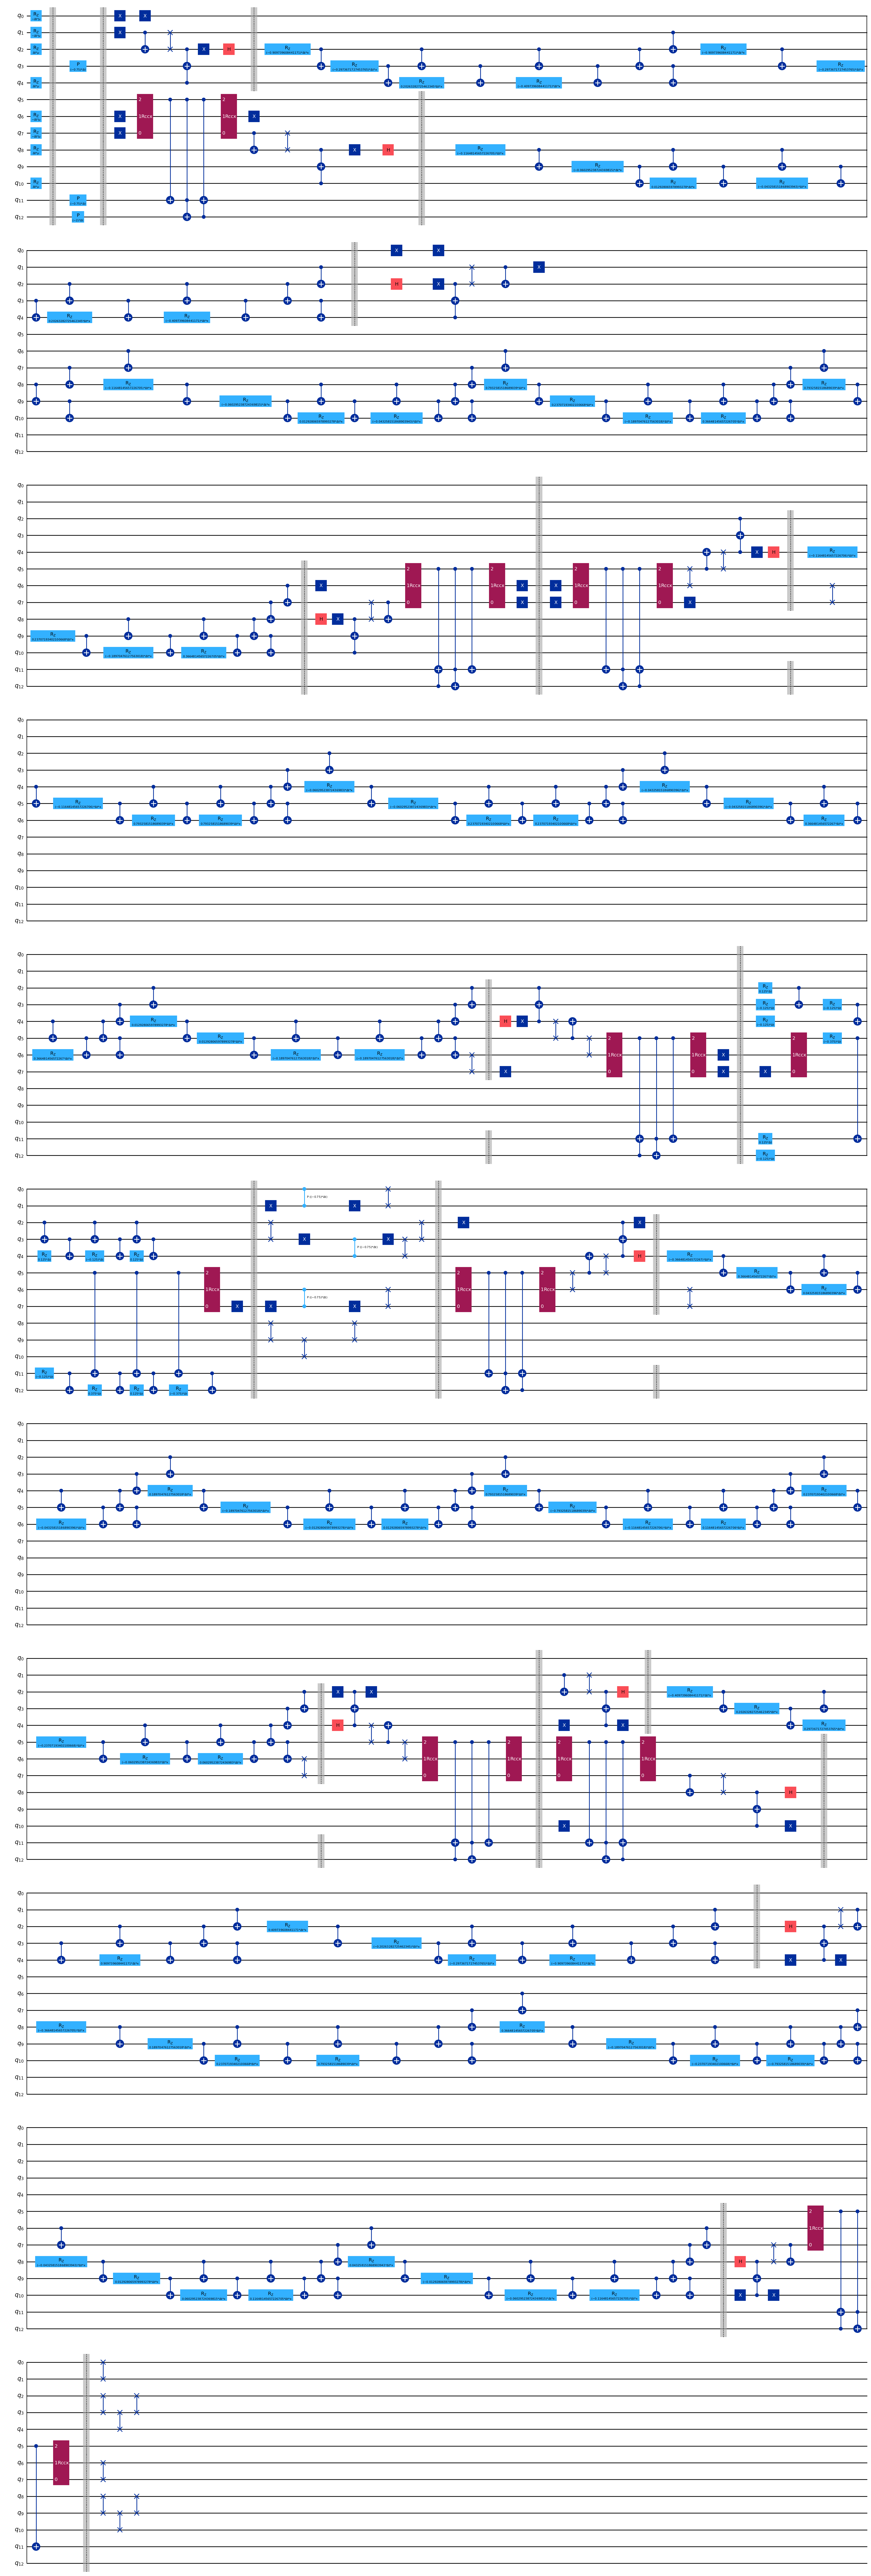

In [7]:
full_circuit[0].draw("mpl", fold=50)

In [8]:
from qiskit.circuit import CircuitInstruction
from qiskit.circuit.library.standard_gates import XGate
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import QuantumRegister, ClassicalRegister
from lsh_qudit.utils import QubitPlacement, sort_qubits, draw_circuit, clean_array, op_matrix

vSim = list()
for i in range(5):
    vSim.append(list())

qregs = []
for name, isite in full_circuit[1].qubit_labels:
    qregs.append(QuantumRegister(1, name=f'{name}({isite})'))

for iP in range(7):
    qc = QuantumCircuit(*qregs)
    qc.data.insert(0, CircuitInstruction(XGate(label=None), [0], []))
    qc.data.insert(0, CircuitInstruction(XGate(label=None), [4], []))
    qc.data.insert(0, CircuitInstruction(XGate(label=None), [3], []))
    qc.data.insert(0, CircuitInstruction(XGate(label=None), [8], []))
    qc.data.insert(0, CircuitInstruction(XGate(label=None), [9], []))
    qc.data.insert(0, CircuitInstruction(XGate(label=None), [12], []))
    
    for iStep in range(iP):
        qc.append(full_circuit[0].assign_parameters({mass_mu: mu, time_step: dt, interaction_x: 1.00}), range(13))
    
    qc.measure_all()
    pm_ideal = generate_preset_pass_manager(backend=AerSimulator(), optimization_level=0)
    samplerV2_sim = Sampler(AerSimulator())
    result = samplerV2_sim.run([(pm_ideal.run(qc.decompose()))], shots=100000).result()[0]
    raw_counts   = result.data.meas.get_counts()
    prob_sim = {i: raw_counts[i]/100000 for i in raw_counts.keys()}
    print(f'Sim Result)')
    print(f'{prob_sim}')
    ret_exp = CalcExpectation_Old(prob_sim, 0)
    for i in range(5):
        vSim[i].append(ret_exp[i])

for i in range(5):
    with open("../savefiles/Sim.txt", mode="a") as f:
        if i==0:
            print(f"{{{{{', '.join(map(str, vSim[i]))}}},", file=f)
        elif i==4:
            print(f"{{{', '.join(map(str, vSim[i]))}}}}}", file=f)
        else:
            print(f"{{{', '.join(map(str, vSim[i]))}}},", file=f)            

Sim Result)
{'1001100011001': 1.0}
# of discarded = 0
site 0 : 0.75
site 1 : 2.0
site 2 : 2.0
site 3 : 0.75
site 4 : 0.0
site 5 : 0.0
Sim Result)
{'0010000010100': 0.4668, '0010010010000': 0.19371, '0101011010000': 0.13144, '0010000000101': 0.01899, '0010010001001': 0.02203, '0111100010000': 0.08027, '0101011001001': 0.01422, '0111100001001': 0.00912, '0001001010100': 0.05003, '0001001000101': 0.00204, '1001100011001': 0.00994, '0101000011101': 0.00133, '0101101010000': 8e-05}
# of discarded = 0
site 0 : 0.058252500000000006
site 1 : 0.35903
site 2 : 0.23637750000000005
site 3 : 0.7500000000000001
site 4 : 0.0
site 5 : 0.0
Sim Result)
{'0101011001001': 0.43393, '0010010001001': 0.06982, '0111100001001': 0.12573, '0010011000000': 0.23958, '0001001010100': 0.01948, '0010010010000': 0.0094, '1001100011001': 0.01203, '0101011010000': 0.01877, '0001001000101': 0.00197, '0001001000011': 0.01591, '0010000010100': 0.00884, '0010000000101': 0.00347, '0101101001001': 0.00396, '0011101000000': 0.

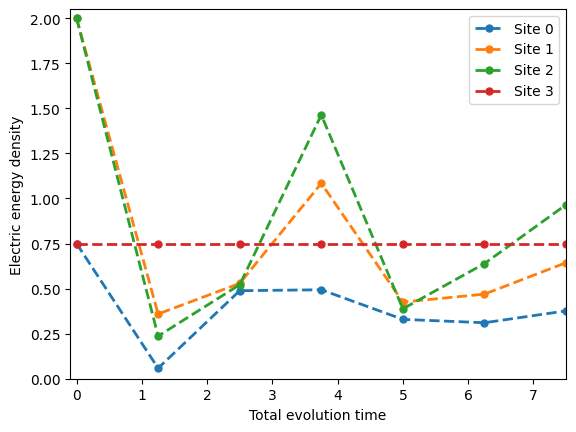

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Data
x = list()
for i in range(7):
    x.append(i*dt)

fig, ax = plt.subplots()
ax.xaxis.set_major_locator(MultipleLocator(1))

ax.set_ylim(0, 2.05)
ax.set_xlim(-0.1, dt*6)

# Create a line plot
for i in range(4):
    plt.plot(x, vSim[i], linewidth=2, linestyle='dashed', marker='o', markersize=5, label='Site {}'.format(i))

# Add labels and title
plt.xlabel('Total evolution time')
plt.ylabel('Electric energy density')
#plt.title('My Line Plot')

# Add legend
plt.legend()

# Show the plot
plt.show()

## Execution on Quantinuum

In [10]:
from pytket.extensions.qiskit import qiskit_to_tk
from pytket.utils import gate_counts
import datetime

import qnexus as qnx
qnx.login()

Already logged in. Tokens are valid.


In [11]:
import qnexus as qnx

#project = qnx.projects.get_or_create(name="EmuStudy_4Site")
project = qnx.projects.get_or_create(name="LSH_LGT")
qnx.context.set_active_project(project)

In [12]:
from quantinuum_schemas.models.quantinuum_systems_noise import UserErrorParams

#device_name="H1-1LE"
device_name="H2-Emulator"
#device_name="H2-2SC"
config = qnx.QuantinuumConfig(device_name=device_name)
user_error_params = UserErrorParams(
    scale=0.9
)

# somehow following settings gives much different results with just scale=0.9
#user_error_params = UserErrorParams(
#    p1_scale=0.9,
#    p2_scale=0.9,
#    meas_scale=0.9,
#    init_scale=0.9,
#    memory_scale=0.9,
#    emission_scale=0.9,
#    crosstalk_scale=0.9,
#    leakage_scale=0.9
#)

conf_nonoise = qnx.QuantinuumConfig(device_name=device_name, noisy_simulation=False)
#myconfig = qnx.QuantinuumConfig(device_name=device_name, error_params=user_error_params)
myconfig = qnx.QuantinuumConfig(device_name=device_name)

### Compilation

#### Preparation for initial states
Redundant X gates are required to keep the ordering of qubits

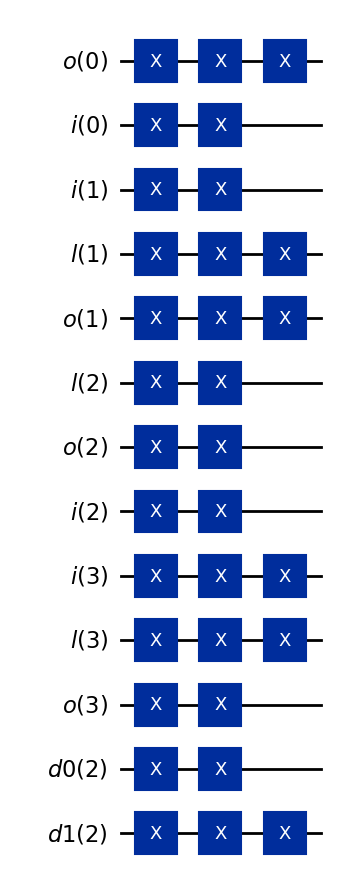

In [13]:
from qiskit.circuit import CircuitInstruction
from qiskit.circuit.library.standard_gates import XGate
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import QuantumRegister, ClassicalRegister
from lsh_qudit.utils import QubitPlacement, sort_qubits, draw_circuit, clean_array, op_matrix

from pytket.extensions.qiskit import qiskit_to_tk
from pytket.utils import gate_counts
import datetime

full_qp = QubitPlacement(
    [('o', 0), ('i', 0)]
    + [('i', 1), ('l', 1), ('o', 1)]
    + [('l', 2), ('o', 2), ('i', 2)]
    + [('i', 3), ('l', 3), ('o', 3)]
    + [('d0', 2), ('d1', 2)]
)


#full_circuit = trotter_step_circuit(num_sites, dt, mu, x, qp=full_qp,
full_circuit = trotter_step_circuit(num_sites, time_step, mass_mu, interaction_x, qp=full_qp,
                                    max_left_flux=0, max_right_flux=1, with_barrier=True)


qregs = []
for name, isite in full_circuit[1].qubit_labels:
    qregs.append(QuantumRegister(1, name=f'{name}({isite})'))

qc = QuantumCircuit(*qregs)
qc.data.insert(0, CircuitInstruction(XGate(label=None), [0], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [4], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [3], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [8], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [9], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [12], []))

for i in range(len(qregs)):
    qc.data.insert(0, CircuitInstruction(XGate(label=None), [i], []))
    qc.data.insert(0, CircuitInstruction(XGate(label=None), [i], []))

qc.draw("mpl")

In [17]:
from pytket.extensions.qiskit import qiskit_to_tk
from pytket.utils import gate_counts
import datetime
qnx.context.set_active_project(project)

qc_tket_initonly = qiskit_to_tk(qc)

jobname_suffix = datetime.datetime.now().strftime("%Y_%m_%d-%H-%M-%S")
ref = qnx.circuits.upload(circuit=qc_tket_initonly, name=f"test-{jobname_suffix}")
ref_compile_job = qnx.start_compile_job(
    programs=[ref],
    backend_config=myconfig,
    optimisation_level=0, # Compile the circuit without optimization, otherwise intentional redundant X gates will be removed
    name=f"compilation-4site-initonly-{jobname_suffix}",
)

#### Preparation for 1-step trotterized circuit
Compilation with initial states gives lower number of gates

In [21]:
#full_circuit = trotter_step_circuit(num_sites, dt, mu, x, qp=full_qp,
full_circuit = trotter_step_circuit(num_sites, time_step, mass_mu, interaction_x, qp=full_qp,
                                    max_left_flux=0, max_right_flux=1, with_barrier=True)
precompiled = precompile_pm.run(full_circuit[0])
qregs = []
for name, isite in full_circuit[1].qubit_labels:
    qregs.append(QuantumRegister(1, name=f'{name}({isite})'))

qc = QuantumCircuit(*qregs)

qc.data.insert(0, CircuitInstruction(XGate(label=None), [0], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [4], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [3], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [8], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [9], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [12], []))

qc.append(full_circuit[0].assign_parameters({mass_mu: mu, time_step: dt, interaction_x: 1.00}), range(13))
#qc.append(full_circuit[0].assign_parameters({mass_mu: mu, time_step: dt, interaction_x: 1.00}), range(13))
#qc.append(full_circuit[0].assign_parameters({mass_mu: mu, time_step: dt, interaction_x: 1.00}), range(13))
#qc.append(precompiled.assign_parameters({mass_mu: mu, time_step: dt, interaction_x: 1.00}), range(13))

#qc.measure_all()

In [49]:
from pytket.extensions.qiskit import qiskit_to_tk
from pytket.utils import gate_counts
import datetime
qnx.context.set_active_project(project)

qc_tket_initfull_nomeas = qiskit_to_tk(qc.decompose().decompose())

jobname_suffix = datetime.datetime.now().strftime("%Y_%m_%d-%H-%M-%S")
ref = qnx.circuits.upload(circuit=qc_tket_initfull_nomeas, name=f"test-{jobname_suffix}")
ref_compile_job = qnx.start_compile_job(
    programs=[ref],
    backend_config=myconfig,
    optimisation_level=3,
    name=f"compilation-4site-initfull-nomeas-{jobname_suffix}",
)

#### Preparation for the measurement part

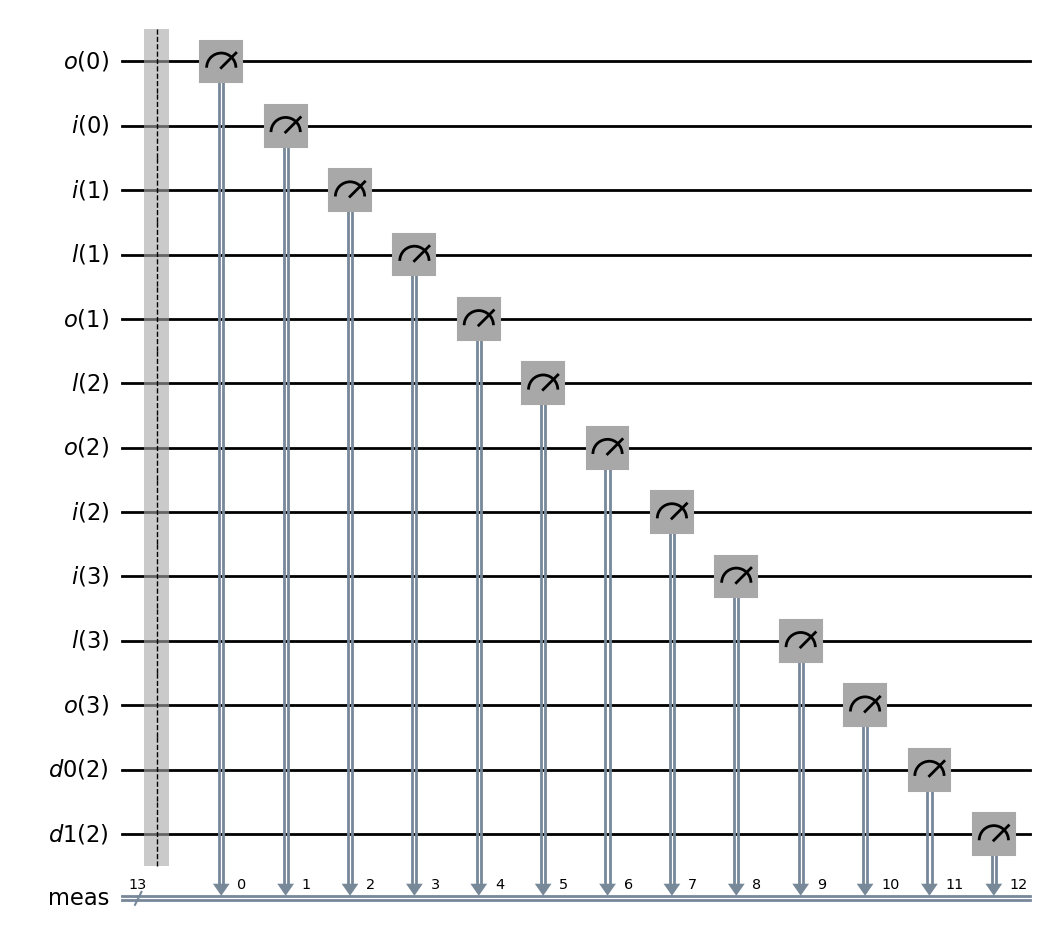

In [73]:
#full_circuit = trotter_step_circuit(num_sites, dt, mu, x, qp=full_qp,
full_circuit = trotter_step_circuit(num_sites, time_step, mass_mu, interaction_x, qp=full_qp,
                                    max_left_flux=0, max_right_flux=1, with_barrier=True)
precompiled = precompile_pm.run(full_circuit[0])
qregs = []
for name, isite in full_circuit[1].qubit_labels:
    qregs.append(QuantumRegister(1, name=f'{name}({isite})'))

qc = QuantumCircuit(*qregs)
qc.measure_all()
qc.decompose().draw("mpl")

In [74]:
from pytket.extensions.qiskit import qiskit_to_tk
from pytket.utils import gate_counts
import datetime
qnx.context.set_active_project(project)

qc_tket_measonly = qiskit_to_tk(qc.decompose())

jobname_suffix = datetime.datetime.now().strftime("%Y_%m_%d-%H-%M-%S")
ref = qnx.circuits.upload(circuit=qc_tket_measonly, name=f"test-{jobname_suffix}")
ref_compile_job = qnx.start_compile_job(
    programs=[ref],
    backend_config=myconfig,
    optimisation_level=0,
    name=f"compilation-4site-measonly-{jobname_suffix}",
)

### Circuit construction and job submission to Qnexus

In [14]:
# init-only
ref = qnx.client.jobs.get(id='07958d40-065f-443d-85d0-7910f705d480')
ref_compiled_circuit = qnx.jobs.results(ref)[0].get_output()
tket_init = ref_compiled_circuit.download_circuit()

# 1-step full no meas
ref = qnx.client.jobs.get(id='cd1b93c8-4673-445e-8a58-7030c1fbb2e9')
ref_compiled_circuit = qnx.jobs.results(ref)[0].get_output()
tket_initfull = ref_compiled_circuit.download_circuit()
print(gate_counts(tket_initfull))

# measurement only
ref = qnx.client.jobs.get(id='d4a5cede-02d2-4e90-a0e7-35a8fbe076c5')
ref_compiled_circuit = qnx.jobs.results(ref)[0].get_output()
tket_meas = ref_compiled_circuit.download_circuit()

Counter({OpType.PhasedX: 296, OpType.ZZPhase: 226, OpType.Rz: 13})


In [107]:
import json
import datetime
import qnexus as qnx

PROJECT_NAME = "LSH_LGT"
N_SHOTS = 1000
SAVE_FILE = "../savefiles/qnexus_execute_initfull_sf1_job_ids.json"

project = qnx.projects.get_or_create(name=PROJECT_NAME)
qnx.context.set_active_project(project)

job_records = []

for n_full in range(7):
    # Circuit construction
    qctket = tket_init.copy()
    for _ in range(n_full):
        qctket.append(tket_init)
        qctket.append(tket_initfull)
    qctket.append(tket_meas)

    timestamp = datetime.datetime.now().strftime("%Y_%m_%d-%H-%M-%S")
    circuit_name = f"test-initfull-{n_full}step-{timestamp}"
    compile_job_name = f"compilation-initfull-{n_full}step-{timestamp}"
    execute_job_name = f"execution-initfull-{n_full}step-{timestamp}"

    # upload
    circuit_ref = qnx.circuits.upload(
        circuit=qctket,
        project=project,
        name=circuit_name,
    )

    # compile
    compile_job_ref = qnx.start_compile_job(
        programs=[circuit_ref],
        backend_config=myconfig,
        optimisation_level=3,
        name=compile_job_name,
        project=project,
    )

    print(f"[{n_full}] compile job submitted: {compile_job_ref.id}")

    # wait for compile
    qnx.jobs.wait_for(compile_job_ref)

    # get compiled circuit
    compiled_circuit_ref = qnx.jobs.results(compile_job_ref)[0].get_output()

    # execute
    execute_job_ref = qnx.start_execute_job(
        programs=[compiled_circuit_ref],
        n_shots=[N_SHOTS],
        backend_config=myconfig,
        name=execute_job_name,
        project=project,
    )

    print(f"[{n_full}] execute job submitted: {execute_job_ref.id}")

    # save job ID
    job_records.append({
        "n_full": n_full,
        "execute_job_id": str(execute_job_ref.id),
        "execute_job_name": execute_job_name,
        "circuit_name": circuit_name,
        "shots": N_SHOTS,
    })

# save jobID as a json file
with open(SAVE_FILE, "w", encoding="utf-8") as f:
    json.dump(job_records, f, indent=2, ensure_ascii=False)

print(f"Saved execute job IDs to {SAVE_FILE}")

[0] compile job submitted: 3b8a499a-4e91-4a71-b879-00d0d81004ff
[0] execute job submitted: 5c0f9ecc-4db4-46e6-8246-cafe37e23580
[1] compile job submitted: 420c7835-c737-4cdc-8080-dec4399fa9c2
[1] execute job submitted: 9fbe2a46-7ea1-4803-9878-c2704fc99300
[2] compile job submitted: 4737f721-f200-4abe-a669-52df71bbaa1d
[2] execute job submitted: 9df669e9-741a-45ce-90a3-093a418d4d76
[3] compile job submitted: 5d522b0b-34a6-4a7c-a600-c07be8e48554
[3] execute job submitted: ccd7fbdd-8940-4909-a1b9-4431f17d0055
[4] compile job submitted: f83695ce-e4f3-4185-9280-29f2bbd72e3a
[4] execute job submitted: d9e6cd7d-92ba-4669-a2cd-ed52c147f569
[5] compile job submitted: b6eee0db-98f0-4832-9482-bce029573437
[5] execute job submitted: ef54cf37-4585-4272-8f7c-c15c8897f971
[6] compile job submitted: e6cc5151-862c-443a-97fd-399a1dd0fb7f
[6] execute job submitted: deef393d-53c0-4ac8-96aa-b8660c4ba99b
Saved execute job IDs to qnexus_execute_initfull_sf1_job_ids.json


#### Test cicuits initialized with zero states

In [15]:
import json
import datetime
import qnexus as qnx

PROJECT_NAME = "LSH_LGT"
N_SHOTS = 1000
SAVE_FILE = "../savefiles/qnexus_execute_initfull_sf1_zeroinit_job_ids.json"

project = qnx.projects.get_or_create(name=PROJECT_NAME)
qnx.context.set_active_project(project)

job_records = []

for n_full in range(6):
    # Circuit construction
    qctket = tket_init.copy()
    qctket.append(tket_initfull)
    for _ in range(n_full):
        qctket.append(tket_init)
        qctket.append(tket_initfull)
    qctket.append(tket_meas)

    timestamp = datetime.datetime.now().strftime("%Y_%m_%d-%H-%M-%S")
    circuit_name = f"test-initfull-zeroinit-{n_full+1}step-{timestamp}"
    compile_job_name = f"compilation-initfull-zeroinit-{n_full+1}step-{timestamp}"
    execute_job_name = f"execution-initfull-zeroinit-{n_full+1}step-{timestamp}"

    # upload
    circuit_ref = qnx.circuits.upload(
        circuit=qctket,
        project=project,
        name=circuit_name,
    )

    # compile
    compile_job_ref = qnx.start_compile_job(
        programs=[circuit_ref],
        backend_config=myconfig,
        optimisation_level=3,
        name=compile_job_name,
        project=project,
    )

    print(f"[{n_full}] compile job submitted: {compile_job_ref.id}")

    qnx.jobs.wait_for(compile_job_ref)

    compiled_circuit_ref = qnx.jobs.results(compile_job_ref)[0].get_output()

    # execute
    execute_job_ref = qnx.start_execute_job(
        programs=[compiled_circuit_ref],
        n_shots=[N_SHOTS],
        backend_config=myconfig,
        name=execute_job_name,
        project=project,
    )

    print(f"[{n_full}] execute job submitted: {execute_job_ref.id}")

    job_records.append({
        "n_full": n_full,
        "execute_job_id": str(execute_job_ref.id),
        "execute_job_name": execute_job_name,
        "circuit_name": circuit_name,
        "shots": N_SHOTS,
    })

with open(SAVE_FILE, "w", encoding="utf-8") as f:
    json.dump(job_records, f, indent=2, ensure_ascii=False)

print(f"Saved execute job IDs to {SAVE_FILE}")

[0] compile job submitted: 83c5d9ae-88c4-4ac2-8ab4-6f17b88b80af
[0] execute job submitted: e492c247-d1a2-4566-9fe2-b5bd75b08bf2
[1] compile job submitted: 01231fd4-b5b2-4e09-8cd6-c8e0af20bf0a
[1] execute job submitted: 1fa61a6e-0716-48d5-9e00-2b1bd32ae52a
[2] compile job submitted: 638a007d-419f-444d-a590-8d071a844f1b
[2] execute job submitted: f1390a55-410e-4806-a821-fbd37fea0e55
[3] compile job submitted: 76773a99-bad4-4711-8205-e1a9f05ad452
[3] execute job submitted: 4910ca26-124d-4fdf-8ab7-cbeb8b3810e3
[4] compile job submitted: 4d0dbef4-b553-4dc9-9c4f-4f53c6488666
[4] execute job submitted: 1c18be23-c03e-4d18-83aa-3dd947701f94
[5] compile job submitted: 7aae01e4-623a-410a-a017-e727b7c31c92
[5] execute job submitted: 9491628b-a489-4d13-b88c-42ef09a3ad34
Saved execute job IDs to ../savefiles/qnexus_execute_initfull_sf1_zeroinit_job_ids.json


#### Test circuits with pair circuits

In [109]:
import json
import datetime
import qnexus as qnx

PROJECT_NAME = "LSH_LGT"
N_SHOTS = 1000
SAVE_FILE = "../savefiles/qnexus_execute_initfull_sf1_pair_job_ids.json"

project = qnx.projects.get_or_create(name=PROJECT_NAME)
qnx.context.set_active_project(project)

job_records = []

for n_full in range(3):
    # Circuit construction
    qctket = tket_init.copy()
    for _ in range(n_full+1):
        qctket.append(tket_initfull)
        qctket.append(tket_initfull.dagger())
    qctket.append(tket_meas)

    timestamp = datetime.datetime.now().strftime("%Y_%m_%d-%H-%M-%S")
    circuit_name = f"test-initfull-{n_full+1}step-{timestamp}"
    compile_job_name = f"compilation-initfull-pair-{n_full+1}step-{timestamp}"
    execute_job_name = f"execution-initfull-pair-{n_full+1}step-{timestamp}"

    # upload
    circuit_ref = qnx.circuits.upload(
        circuit=qctket,
        project=project,
        name=circuit_name,
    )

    # compile
    compile_job_ref = qnx.start_compile_job(
        programs=[circuit_ref],
        backend_config=myconfig,
        optimisation_level=0,
        name=compile_job_name,
        project=project,
    )

    print(f"[{n_full}] compile job submitted: {compile_job_ref.id}")

    qnx.jobs.wait_for(compile_job_ref)

    compiled_circuit_ref = qnx.jobs.results(compile_job_ref)[0].get_output()

    # execute
    execute_job_ref = qnx.start_execute_job(
        programs=[compiled_circuit_ref],
        n_shots=[N_SHOTS],
        backend_config=myconfig,
        name=execute_job_name,
        project=project,
    )

    print(f"[{n_full}] execute job submitted: {execute_job_ref.id}")

    job_records.append({
        "n_full": n_full,
        "execute_job_id": str(execute_job_ref.id),
        "execute_job_name": execute_job_name,
        "circuit_name": circuit_name,
        "shots": N_SHOTS,
    })

with open(SAVE_FILE, "w", encoding="utf-8") as f:
    json.dump(job_records, f, indent=2, ensure_ascii=False)

print(f"Saved execute job IDs to {SAVE_FILE}")

[0] compile job submitted: 3f57b0a3-00ae-402a-a6f2-7656cb1c8b74
[0] execute job submitted: 8671b276-99f6-4f95-8e19-cfa2192719b6
[1] compile job submitted: c3f56402-8c57-4913-bfc9-d698c36cffe0
[1] execute job submitted: 15065aba-8358-4111-8e93-fabb33b1ce0e
[2] compile job submitted: b3b1d09a-827d-4fdd-baea-3abe6182dc6b
[2] execute job submitted: 1a3fd2db-c5a8-43c1-a1c9-efbb465eb7ea
Saved execute job IDs to qnexus_execute_initfull_sf1_pair_job_ids.json


## Dump observables of execution results

In [23]:
import json
import qnexus as qnx

PROJECT_NAME = "LSH_LGT"
SAVE_FILE = "../savefiles/qnexus_execute_initfull_sf1_job_ids.json"

project = qnx.projects.get_or_create(name=PROJECT_NAME)
qnx.context.set_active_project(project)

with open(SAVE_FILE, "r", encoding="utf-8") as f:
    job_records = json.load(f)

empirical_distributions = [None] * 7

for rec in job_records:
    n_full = rec["n_full"]
    job_id = rec["execute_job_id"]

    print(f"Fetching result for n_full={n_full}, job_id={job_id}")

    execute_job_ref = qnx.client.jobs.get(id=job_id)

    qnx.jobs.wait_for(execute_job_ref)

    ref_result = qnx.jobs.results(execute_job_ref)[0]
    backend_result = ref_result.download_result()
    dist = backend_result.get_empirical_distribution()

    empirical_distributions[n_full] = dist

    DumpInfoQnx(dist, f'../savefiles/{device_name}_initfull_sf1_{n_full}step.txt')
    
print("Done.")
#print(empirical_distributions)

Fetching result for n_full=0, job_id=5c0f9ecc-4db4-46e6-8246-cafe37e23580
Fetching result for n_full=1, job_id=9fbe2a46-7ea1-4803-9878-c2704fc99300
Fetching result for n_full=2, job_id=9df669e9-741a-45ce-90a3-093a418d4d76
Fetching result for n_full=3, job_id=ccd7fbdd-8940-4909-a1b9-4431f17d0055
Fetching result for n_full=4, job_id=d9e6cd7d-92ba-4669-a2cd-ed52c147f569
Fetching result for n_full=5, job_id=ef54cf37-4585-4272-8f7c-c15c8897f971
Fetching result for n_full=6, job_id=deef393d-53c0-4ac8-96aa-b8660c4ba99b
Done.


In [16]:
import json
import qnexus as qnx

PROJECT_NAME = "LSH_LGT"
SAVE_FILE = "../savefiles/qnexus_execute_initfull_sf1_zeroinit_job_ids.json"

project = qnx.projects.get_or_create(name=PROJECT_NAME)
qnx.context.set_active_project(project)

with open(SAVE_FILE, "r", encoding="utf-8") as f:
    job_records = json.load(f)

empirical_distributions = [None] * 6

for rec in job_records:
    n_full = rec["n_full"]
    job_id = rec["execute_job_id"]

    print(f"Fetching result for n_full={n_full}, job_id={job_id}")

    execute_job_ref = qnx.client.jobs.get(id=job_id)

    qnx.jobs.wait_for(execute_job_ref)

    ref_result = qnx.jobs.results(execute_job_ref)[0]
    backend_result = ref_result.download_result()
    dist = backend_result.get_empirical_distribution()

    empirical_distributions[n_full] = dist

    DumpInfoQnx(dist, f'../savefiles/{device_name}_initfull_sf1_zeroinit_{n_full+1}step.txt')
    
print("Done.")
#print(empirical_distributions)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Fetching result for n_full=0, job_id=e492c247-d1a2-4566-9fe2-b5bd75b08bf2
Fetching result for n_full=1, job_id=1fa61a6e-0716-48d5-9e00-2b1bd32ae52a
Fetching result for n_full=2, job_id=f1390a55-410e-4806-a821-fbd37fea0e55
Fetching result for n_full=3, job_id=4910ca26-124d-4fdf-8ab7-cbeb8b3810e3
Fetching result for n_full=4, job_id=1c18be23-c03e-4d18-83aa-3dd947701f94
Fetching result for n_full=5, job_id=9491628b-a489-4d13-b88c-42ef09a3ad34
Done.


In [25]:
import json
import qnexus as qnx

PROJECT_NAME = "LSH_LGT"
SAVE_FILE = "../savefiles/qnexus_execute_initfull_sf1_pair_job_ids.json"

project = qnx.projects.get_or_create(name=PROJECT_NAME)
qnx.context.set_active_project(project)

with open(SAVE_FILE, "r", encoding="utf-8") as f:
    job_records = json.load(f)

empirical_distributions = [None] * 3

for rec in job_records:
    n_full = rec["n_full"]
    job_id = rec["execute_job_id"]

    print(f"Fetching result for n_full={n_full}, job_id={job_id}")

    execute_job_ref = qnx.client.jobs.get(id=job_id)

    qnx.jobs.wait_for(execute_job_ref)

    ref_result = qnx.jobs.results(execute_job_ref)[0]
    backend_result = ref_result.download_result()
    dist = backend_result.get_empirical_distribution()

    empirical_distributions[n_full] = dist

    DumpInfoQnx(dist, f'../savefiles/{device_name}_initfull_sf1_pair_{2*n_full+2}step.txt')
    
print("Done.")
#print(empirical_distributions)

Fetching result for n_full=0, job_id=8671b276-99f6-4f95-8e19-cfa2192719b6
Fetching result for n_full=1, job_id=15065aba-8358-4111-8e93-fabb33b1ce0e
Fetching result for n_full=2, job_id=1a3fd2db-c5a8-43c1-a1c9-efbb465eb7ea
Done.


## Plotting code

In [18]:
!root -l -b -q -n '../macro/plot_for_paper_H2_quantinuum.C'


Processing ../macro/plot_for_paper_H2_quantinuum.C...
Load File: ../savefiles/H2-Emulator_initfull_sf1_zeroinit_1step.txt
iStep = 1, j = 0, vObs =  0.0375
iStep = 1, j = 1, vObs =  0.0975
iStep = 1, j = 2, vObs =  0.27575
iStep = 1, j = 3, vObs =  0.066
iStep = 1, j = 4, vObs =  0.00225
Load File: ../savefiles/H2-Emulator_initfull_sf1_zeroinit_2step.txt
iStep = 2, j = 0, vObs =  0.08475
iStep = 2, j = 1, vObs =  0.2275
iStep = 2, j = 2, vObs =  0.73325
iStep = 2, j = 3, vObs =  0.26725
iStep = 2, j = 4, vObs =  0.04275
Load File: ../savefiles/H2-Emulator_initfull_sf1_zeroinit_3step.txt
iStep = 3, j = 0, vObs =  0.08475
iStep = 3, j = 1, vObs =  0.287
iStep = 3, j = 2, vObs =  0.81675
iStep = 3, j = 3, vObs =  0.26675
iStep = 3, j = 4, vObs =  0.03375
Load File: ../savefiles/H2-Emulator_initfull_sf1_zeroinit_4step.txt
iStep = 4, j = 0, vObs =  0.1035
iStep = 4, j = 1, vObs =  0.3495
iStep = 4, j = 2, vObs =  1.03
iStep = 4, j = 3, vObs =  0.3185
iStep = 4, j = 4, vObs =  0.069
Load Fil